# Plots of deterministic results

In [35]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
import scipy.special as sps

## Rate constants

In [36]:
R = 0.00888
K = 0.00772

## $\frac{F_{fast}}{A}$ plot vs. $\frac{N}{A}$

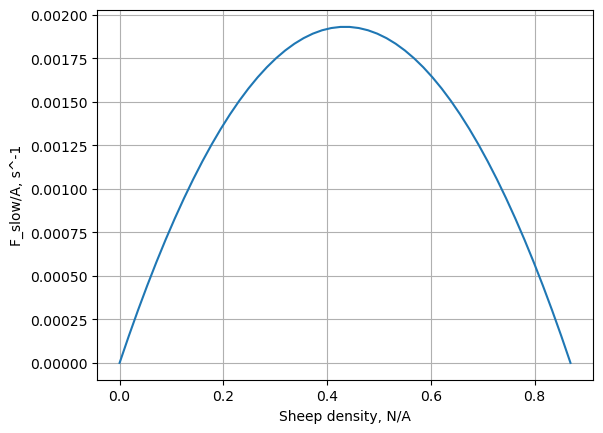

In [37]:
density = np.linspace(0, K/R)
T = np.linspace(1, 3600)

F_fastA = density*R - density**2 * R**2 / K

for i in range(0, F_fastA.size):
    if F_fastA[i] < 0:
        F_fastA[i]=0

f, ax = plt.subplots()

ax.plot(density, F_fastA)

ax.set_xlabel("Sheep density, N/A")
ax.set_ylabel("F_slow/A, s^-1")
ax.grid(True)

plt.show()

## $\frac{F_{slow}}{A}$ plot vs. $\frac{N}{A}$ and $T$

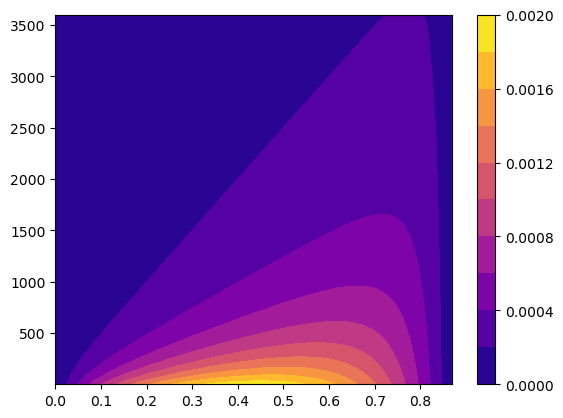

In [38]:
dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

f, ax = plt.subplots()

im_ptr = ax.contourf(dd, TT, F_slowA, levels=10, cmap="plasma")

cb = plt.colorbar(im_ptr, ax=ax)

plt.show()

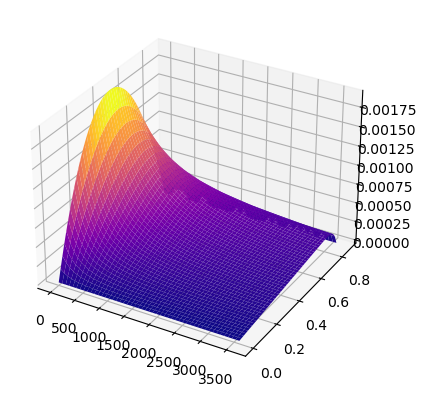

In [39]:
dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

for i in range(0, F_slowA.shape[0]):
    for j in range(0, F_slowA.shape[1]):
        if F_slowA[i][j] < 0:
            F_slowA[i][j] = 0.0001

f, ax = plt.subplots(subplot_kw=dict(projection='3d'))

ax.plot_surface(TT, dd, F_slowA, cmap="plasma")

plt.show()

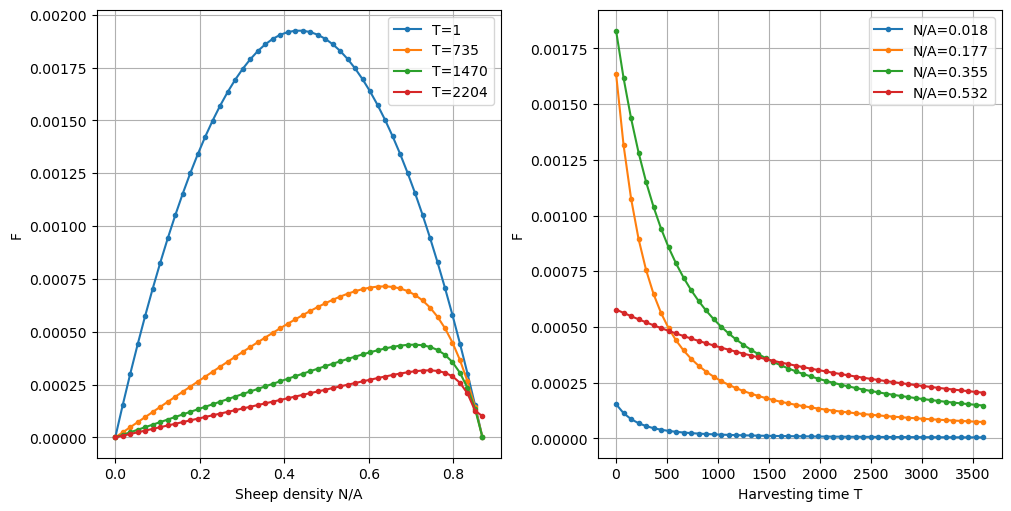

In [40]:
f, axs = plt.subplots(nrows=1, ncols=2, layout="constrained", figsize=(10,5))

axs[0].plot(density, F_slowA[0,0:], ".-", label="T={0:.0f}".format(T[0]))
axs[0].plot(density, F_slowA[10,0:], ".-", label="T={0:.0f}".format(T[10]))
axs[0].plot(density, F_slowA[20,0:], ".-", label="T={0:.0f}".format(T[20]))
axs[0].plot(density, F_slowA[30,0:], ".-", label="T={0:.0f}".format(T[30]))

axs[0].set_xlabel("Sheep density N/A")
axs[0].set_ylabel("F")

axs[1].plot(T, F_slowA[0:,1], ".-", label="N/A={0:.3f}".format(density[1]))
axs[1].plot(T, F_slowA[0:,15], ".-", label="N/A={0:.3f}".format(density[10]))
axs[1].plot(T, F_slowA[0:,30], ".-", label="N/A={0:.3f}".format(density[20]))
axs[1].plot(T, F_slowA[0:,45], ".-", label="N/A={0:.3f}".format(density[30]))

axs[1].set_xlabel("Harvesting time T")
axs[1].set_ylabel("F")

axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)

plt.show()

## Optimal sheep density vs T for slow farmer

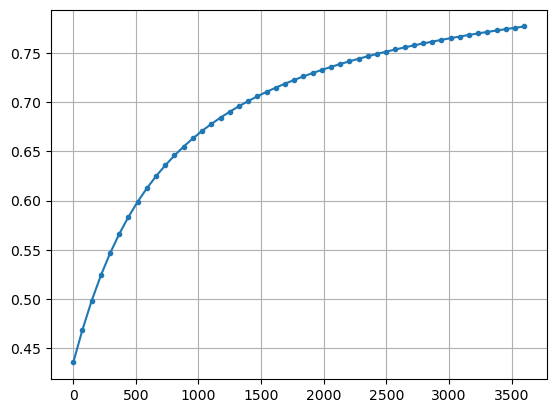

In [41]:
f, ax = plt.subplots()

ax.plot(T, K*(sps.lambertw(np.exp(T*R+1))-1)/(T*R**2),".-")

ax.grid(True)

plt.show()

## maximum $\frac{F_{slow}}{A}$ vs $T$

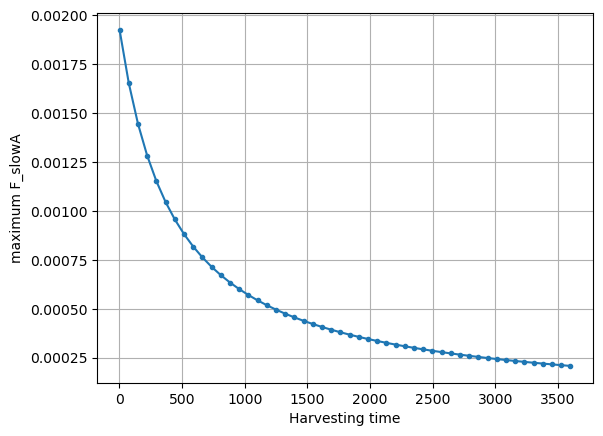

In [42]:
F_slowA = K*(sps.lambertw(np.exp(T*R+1))-1)*(1-np.exp(-T*R+sps.lambertw(np.exp(T*R+1))-1))/(R**2*T**2)

f, ax = plt.subplots()

ax.plot(T, F_slowA, ".-")

ax.set_xlabel("Harvesting time")
ax.set_ylabel("maximum F_slowA")

ax.grid(True)

plt.show()